<a href="https://colab.research.google.com/github/AdeelAsghar11/deep-learning-playground/blob/main/emotion_detection_text_ML_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fazalkhan09/dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dataset' dataset.
Path to dataset files: /kaggle/input/dataset


In [6]:
# Cell 2 — Inspect downloaded files
import os

for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/dataset/merged_training.pkl


In [7]:
# Cell 3 — Load dataset
import pandas as pd

df = pd.read_pickle(f"{path}/merged_training.pkl")

print(df.shape)
print(df.dtypes)
print(df.head())

(416809, 2)
text        object
emotions    object
dtype: object
                                                     text emotions
27383   i feel awful about it too because it s my job ...  sadness
110083                              im alone i feel awful  sadness
140764  ive probably mentioned this before but i reall...      joy
100071           i was feeling a little low few days back  sadness
2837    i beleive that i am much more sensitive to oth...     love


emotions
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64

Class %:
emotions
joy         33.8
sadness     29.1
anger       13.8
fear        11.4
love         8.3
surprise     3.6
Name: proportion, dtype: float64


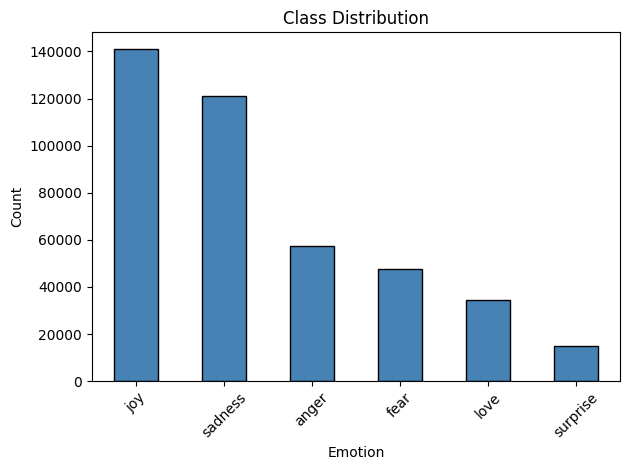

In [8]:
# Cell 4 — Class distribution
import matplotlib.pyplot as plt

print(df['emotions'].value_counts())
print("\nClass %:")
print(df['emotions'].value_counts(normalize=True).mul(100).round(1))

df['emotions'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Cell 5 — Balance dataset + add text length column
from sklearn.utils import resample

# Undersample to match smallest class
min_count = df['emotions'].value_counts().min()  # 14972

balanced_df = pd.concat([
    resample(df[df['emotions'] == label],
             replace=False,
             n_samples=min_count,
             random_state=42)
    for label in df['emotions'].unique()
]).reset_index(drop=True)

print("Balanced shape:", balanced_df.shape)
print(balanced_df['emotions'].value_counts())

# Add text length — useful for EDA next
balanced_df['text_length'] = balanced_df['text'].apply(lambda x: len(x.split()))

print("\nText length stats:")
print(balanced_df['text_length'].describe().round(1))

Balanced shape: (89832, 2)
emotions
sadness     14972
joy         14972
love        14972
anger       14972
fear        14972
surprise    14972
Name: count, dtype: int64

Text length stats:
count    89832.0
mean        19.4
std         11.1
min          1.0
25%         11.0
50%         17.0
75%         26.0
max        100.0
Name: text_length, dtype: float64


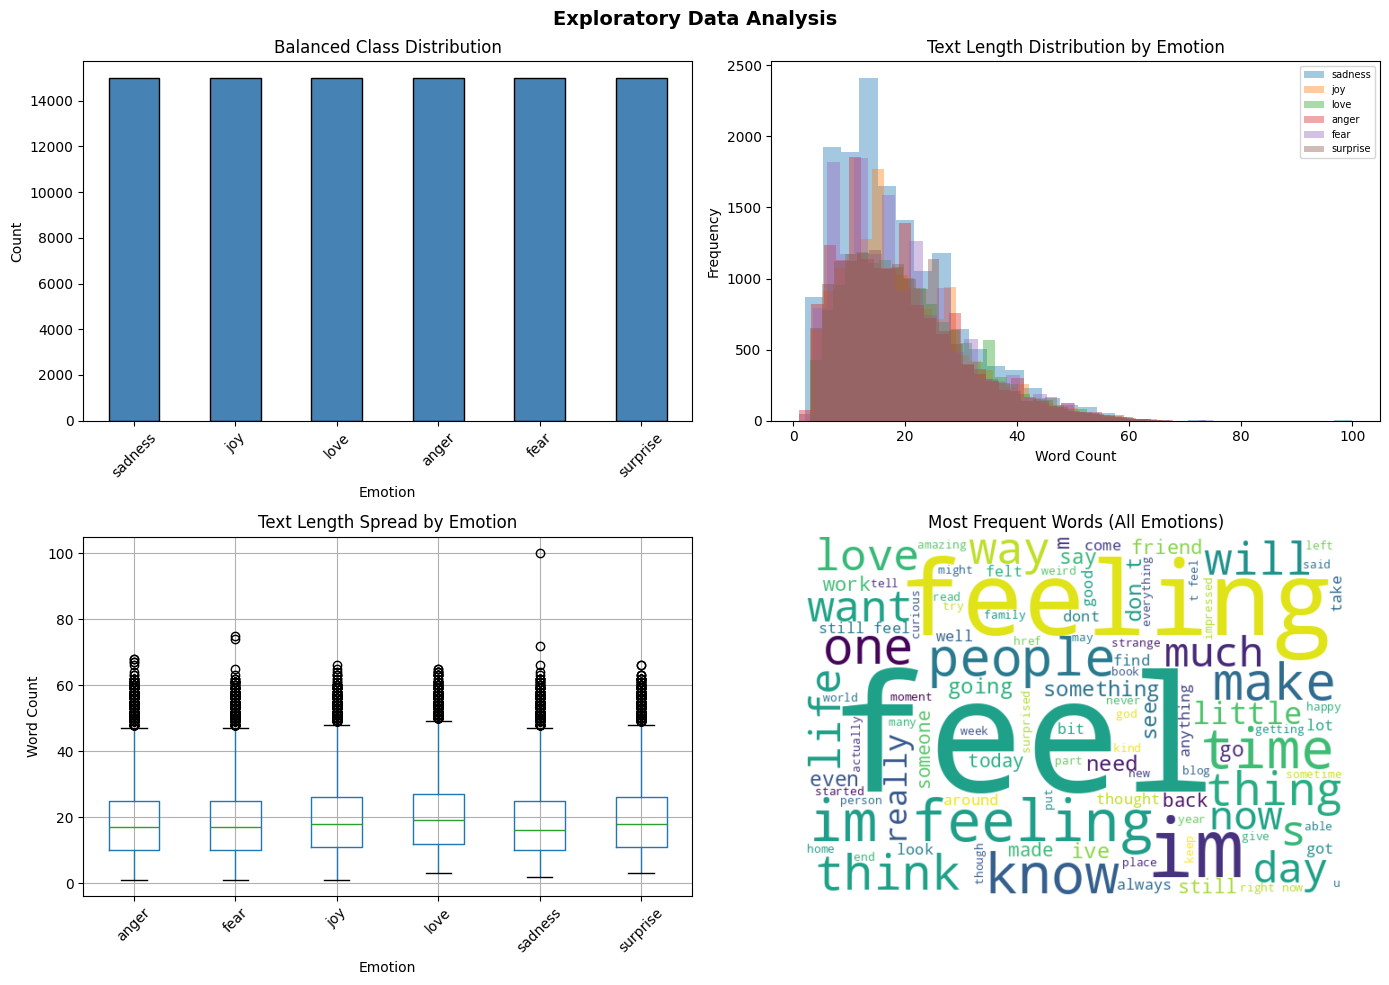

In [10]:
# Cell 6 — EDA Visualisations
from wordcloud import WordCloud
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Balanced class distribution
balanced_df['emotions'].value_counts().plot(kind='bar', ax=axes[0,0],
                                             color='steelblue', edgecolor='black')
axes[0,0].set_title('Balanced Class Distribution')
axes[0,0].set_xlabel('Emotion')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Text length distribution per emotion
for emotion in balanced_df['emotions'].unique():
    subset = balanced_df[balanced_df['emotions'] == emotion]['text_length']
    axes[0,1].hist(subset, alpha=0.4, label=emotion, bins=30)
axes[0,1].set_title('Text Length Distribution by Emotion')
axes[0,1].set_xlabel('Word Count')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend(fontsize=7)

# 3. Boxplot of text length per emotion
balanced_df.boxplot(column='text_length', by='emotions', ax=axes[1,0])
axes[1,0].set_title('Text Length Spread by Emotion')
axes[1,0].set_xlabel('Emotion')
axes[1,0].set_ylabel('Word Count')
plt.sca(axes[1,0])
plt.xticks(rotation=45)

# 4. Word cloud for all text combined
all_text = ' '.join(balanced_df['text'].values)
wc = WordCloud(width=600, height=400, background_color='white',
               max_words=100).generate(all_text)
axes[1,1].imshow(wc, interpolation='bilinear')
axes[1,1].axis('off')
axes[1,1].set_title('Most Frequent Words (All Emotions)')

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Cell 7 — Preprocessing + Train/Val/Test split + Baseline
import re
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

# --- Text cleaning ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)      # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

balanced_df['clean_text'] = balanced_df['text'].apply(clean_text)

# --- Encode labels ---
le = LabelEncoder()
balanced_df['label'] = le.fit_transform(balanced_df['emotions'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# --- Split ---
X = balanced_df['clean_text']
y = balanced_df['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# --- Baseline: Majority class classifier ---
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("\n--- Baseline (Majority Class) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_dummy, average='macro'):.4f}")

Label mapping: {'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

Train: 71865 | Val: 8983 | Test: 8984

--- Baseline (Majority Class) ---
Accuracy : 0.1666
F1 (macro): 0.0476


--- Naive Bayes (Validation) ---
Accuracy : 0.9006
F1 (macro): 0.9004

Classification Report:
              precision    recall  f1-score   support

       anger       0.94      0.90      0.92      1497
        fear       0.90      0.87      0.88      1497
         joy       0.90      0.84      0.87      1497
        love       0.87      0.94      0.90      1498
     sadness       0.92      0.91      0.92      1497
    surprise       0.88      0.95      0.91      1497

    accuracy                           0.90      8983
   macro avg       0.90      0.90      0.90      8983
weighted avg       0.90      0.90      0.90      8983



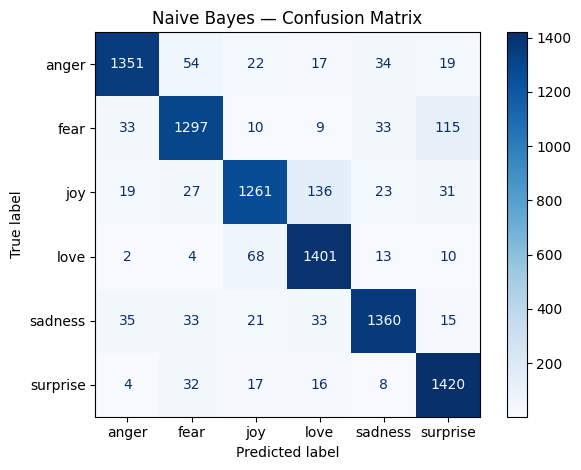

In [12]:
# Cell 8 — Traditional Model 1: Naive Bayes
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Build pipeline ---
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')),
    ('clf', MultinomialNB())
])

# --- Train ---
nb_pipeline.fit(X_train, y_train)

# --- Evaluate on validation set ---
y_pred_nb = nb_pipeline.predict(X_val)

print("--- Naive Bayes (Validation) ---")
print(f"Accuracy : {accuracy_score(y_val, y_pred_nb):.4f}")
print(f"F1 (macro): {f1_score(y_val, y_pred_nb, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_nb, target_names=le.classes_))

# --- Confusion matrix ---
cm = confusion_matrix(y_val, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Naive Bayes — Confusion Matrix')
plt.tight_layout()
plt.show()

In [13]:
# Cell 9 — Naive Bayes Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__alpha': [0.1, 0.5, 1.0]
}

grid_search = GridSearchCV(nb_pipeline, param_grid,
                           cv=3, scoring='f1_macro',
                           n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1 (macro):", round(grid_search.best_score_, 4))

# Evaluate best model on validation
best_nb = grid_search.best_estimator_
y_pred_nb_tuned = best_nb.predict(X_val)

print("\n--- Tuned Naive Bayes (Validation) ---")
print(f"Accuracy : {accuracy_score(y_val, y_pred_nb_tuned):.4f}")
print(f"F1 (macro): {f1_score(y_val, y_pred_nb_tuned, average='macro'):.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'clf__alpha': 1.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best CV F1 (macro): 0.8997

--- Tuned Naive Bayes (Validation) ---
Accuracy : 0.9006
F1 (macro): 0.9004


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'clf__C': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best CV F1 (macro): 0.9282

--- Tuned SVM (Validation) ---
Accuracy : 0.9262
F1 (macro): 0.9258

Classification Report:
              precision    recall  f1-score   support

       anger       0.95      0.92      0.93      1497
        fear       0.92      0.88      0.90      1497
         joy       0.94      0.87      0.91      1497
        love       0.90      0.98      0.94      1498
     sadness       0.95      0.92      0.93      1497
    surprise       0.90      0.99      0.94      1497

    accuracy                           0.93      8983
   macro avg       0.93      0.93      0.93      8983
weighted avg       0.93      0.93      0.93      8983



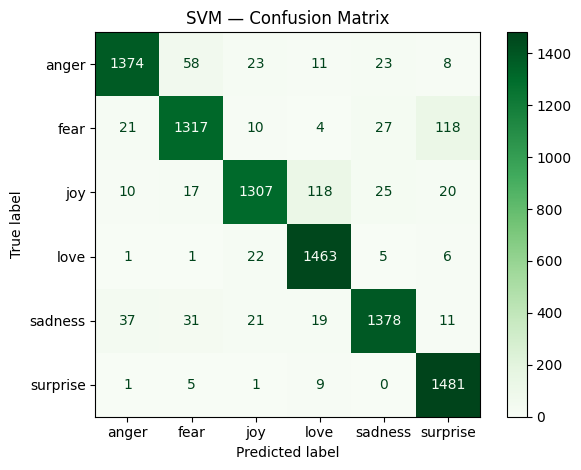

In [14]:
# Cell 10 — Traditional Model 2: SVM + Tuning
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# --- Build pipeline ---
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')),
    ('clf', LinearSVC(random_state=42, max_iter=1000))
])

# --- Tune ---
svm_params = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1.0, 10.0]
}

svm_grid = GridSearchCV(svm_pipeline, svm_params,
                        cv=3, scoring='f1_macro',
                        n_jobs=-1, verbose=1)
svm_grid.fit(X_train, y_train)

print("Best params:", svm_grid.best_params_)
print("Best CV F1 (macro):", round(svm_grid.best_score_, 4))

# --- Evaluate best model ---
best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_val)

print("\n--- Tuned SVM (Validation) ---")
print(f"Accuracy : {accuracy_score(y_val, y_pred_svm):.4f}")
print(f"F1 (macro): {f1_score(y_val, y_pred_svm, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_svm, target_names=le.classes_))

# --- Confusion matrix ---
cm_svm = confusion_matrix(y_val, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=le.classes_)
disp.plot(cmap='Greens')
plt.title('SVM — Confusion Matrix')
plt.tight_layout()
plt.show()

In [15]:
# Cell 11 — Traditional Models Summary Table
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Final test set evaluation for both models
y_pred_nb_test  = best_nb.predict(X_test)
y_pred_svm_test = best_svm.predict(X_test)

# ROC-AUC (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=range(6))

nb_proba  = best_nb.predict_proba(X_test)
svm_score = label_binarize(y_pred_svm_test, classes=range(6))  # LinearSVC has no proba

results = {
    'Model':      ['Baseline', 'Naive Bayes', 'SVM'],
    'Accuracy':   [
        round(accuracy_score(y_test, dummy.predict(X_test)), 4),
        round(accuracy_score(y_test, y_pred_nb_test), 4),
        round(accuracy_score(y_test, y_pred_svm_test), 4)
    ],
    'F1 Macro':   [
        round(f1_score(y_test, dummy.predict(X_test), average='macro'), 4),
        round(f1_score(y_test, y_pred_nb_test, average='macro'), 4),
        round(f1_score(y_test, y_pred_svm_test, average='macro'), 4)
    ],
    'ROC-AUC':    [
        'N/A',
        round(roc_auc_score(y_test_bin, nb_proba, multi_class='ovr'), 4),
        'N/A'
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

      Model  Accuracy  F1 Macro ROC-AUC
   Baseline    0.1666    0.0476     N/A
Naive Bayes    0.9006    0.9004  0.9885
        SVM    0.9268    0.9265     N/A


In [17]:
# Cell 12 — LSTM Setup + Tokenization
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

# --- Tokenize ---
MAX_WORDS = 20000
MAX_LEN   = 50  # covers ~75th percentile of text lengths

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN)

print("Train shape:", X_train_seq.shape)

# --- Build LSTM ---
model_lstm = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

model_lstm.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])
model_lstm.summary()

# --- Train ---
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = model_lstm.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Train shape: (71865, 50)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 108s 186ms/step - accuracy: 0.7238 - loss: 0.7345 - val_accuracy: 0.9256 - val_loss: 0.2366
Epoch 2/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 103s 183ms/step - accuracy: 0.9354 - loss: 0.1940 - val_accuracy: 0.9436 - val_loss: 0.1566
Epoch 3/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 141s 181ms/step - accuracy: 0.9468 - loss: 0.1419 - val_accuracy: 0.9438 - val_loss: 0.1423
Epoch 4/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 102s 182ms/step - accuracy: 0.9532 - loss: 0.1188 - val_accuracy: 0.9478 - val_loss: 0.1391
Epoch 5/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 103s 183ms/step - accuracy: 0.9556 - loss: 0.1079 - val_accuracy: 0.9432 - val_loss: 0.1545
Epoch 6/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 103s 183ms/step - accuracy: 0.9576 - loss: 0.1022 - val_accuracy: 0.9442 - val_loss: 0.1523
Epoch 7/15
562/562 ━━━━━━━━━━━━━━━━━━━━ 102s 182ms/step - accuracy: 0.9597 - loss: 0.0945 - val_accuracy: 0.9442 - val_loss: 0.1585


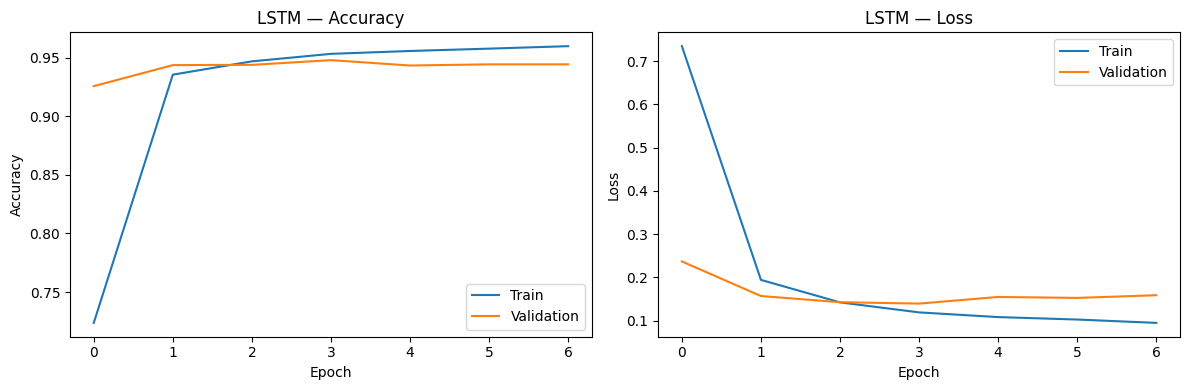

281/281 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step
281/281 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step
--- LSTM (Test) ---
Accuracy : 0.9479
F1 (macro): 0.9478
ROC-AUC  : 0.9967

Classification Report:
              precision    recall  f1-score   support

       anger       0.95      0.94      0.95      1497
        fear       0.92      0.90      0.91      1497
         joy       0.99      0.91      0.95      1498
        love       0.94      0.99      0.96      1497
     sadness       0.99      0.94      0.96      1498
    surprise       0.91      1.00      0.95      1497

    accuracy                           0.95      8984
   macro avg       0.95      0.95      0.95      8984
weighted avg       0.95      0.95      0.95      8984



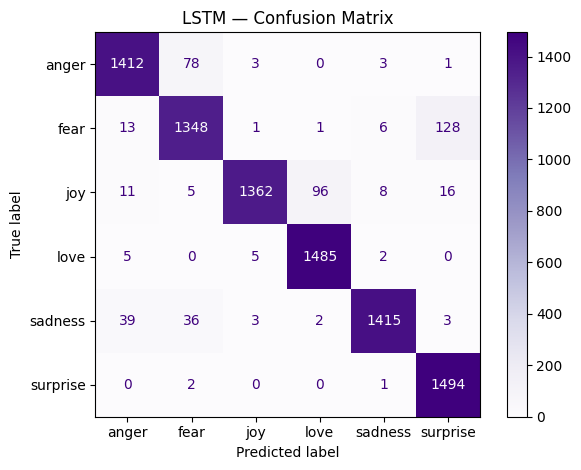

In [18]:
# Cell 13 — LSTM Evaluation + Training Curves
# --- Training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_lstm.history['accuracy'], label='Train')
ax1.plot(history_lstm.history['val_accuracy'], label='Validation')
ax1.set_title('LSTM — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history_lstm.history['loss'], label='Train')
ax2.plot(history_lstm.history['val_loss'], label='Validation')
ax2.set_title('LSTM — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# --- Test evaluation ---
y_pred_lstm     = np.argmax(model_lstm.predict(X_test_seq), axis=1)
y_proba_lstm    = model_lstm.predict(X_test_seq)

print("--- LSTM (Test) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lstm):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_lstm, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_bin, y_proba_lstm, multi_class='ovr'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

# --- Confusion matrix ---
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
ConfusionMatrixDisplay(cm_lstm, display_labels=le.classes_).plot(cmap='Purples')
plt.title('LSTM — Confusion Matrix')
plt.tight_layout()
plt.show()

In [20]:
# Cell 14a — BERT Setup (run this first)
!pip install transformers -q

import torch
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BERT_MODEL   = 'bert-base-uncased'
MAX_LEN_BERT = 64
BATCH_SIZE   = 32
EPOCHS_BERT  = 4

print("Device:", DEVICE)

class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True,
                                   max_length=MAX_LEN_BERT, return_tensors='pt')
        self.labels = torch.tensor(list(labels), dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}, self.labels[idx]

bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL)
train_loader = DataLoader(EmotionDataset(X_train, y_train, bert_tokenizer), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(EmotionDataset(X_val,   y_val,   bert_tokenizer), batch_size=BATCH_SIZE)
test_loader  = DataLoader(EmotionDataset(X_test,  y_test,  bert_tokenizer), batch_size=BATCH_SIZE)

bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=6)
bert_model.to(DEVICE)

optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer,
                num_warmup_steps=len(train_loader),
                num_training_steps=len(train_loader) * EPOCHS_BERT)

print("Setup complete. Ready to train.")

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Setup complete. Ready to train.


In [23]:
# Cell 14b — BERT Training
import sys

for epoch in range(EPOCHS_BERT):
    bert_model.train()
    total_loss, correct = 0, 0
    for batch, labels in train_loader:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        labels  = labels.to(DEVICE)
        outputs = bert_model(**batch, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        correct    += (outputs.logits.argmax(dim=1) == labels).sum().item()

    train_acc = correct / len(X_train)
    print(f"Epoch {epoch+1}/{EPOCHS_BERT} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f}", flush=True)
    sys.stdout.flush()

Epoch 1/4 | Loss: 0.1083 | Train Acc: 0.9562
Epoch 2/4 | Loss: 0.0967 | Train Acc: 0.9590
Epoch 3/4 | Loss: 0.0895 | Train Acc: 0.9620
Epoch 4/4 | Loss: 0.0886 | Train Acc: 0.9620


--- BERT (Test) ---
Accuracy : 0.9545
F1 (macro): 0.9544
ROC-AUC  : 0.9973

Classification Report:
              precision    recall  f1-score   support

       anger       0.97      0.95      0.96      1497
        fear       0.93      0.90      0.92      1497
         joy       0.99      0.92      0.96      1498
        love       0.94      1.00      0.97      1497
     sadness       0.99      0.95      0.97      1498
    surprise       0.91      1.00      0.95      1497

    accuracy                           0.95      8984
   macro avg       0.96      0.95      0.95      8984
weighted avg       0.96      0.95      0.95      8984



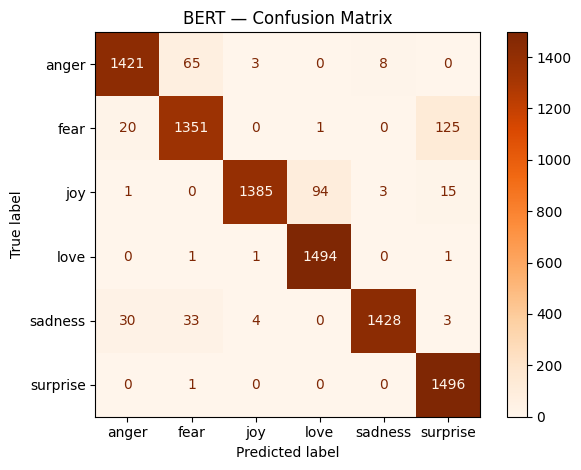

In [24]:
# Cell 15 — BERT Evaluation
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

bert_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch, labels in test_loader:
        batch   = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = bert_model(**batch)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds   = probs.argmax(axis=1)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("--- BERT (Test) ---")
print(f"Accuracy : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 (macro): {f1_score(all_labels, all_preds, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test_bin, all_probs, multi_class='ovr'):.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(all_labels, all_preds), display_labels=le.classes_).plot(cmap='Oranges')
plt.title('BERT — Confusion Matrix')
plt.tight_layout()
plt.show()

In [25]:
# Cell 16 — Final Model Comparison Table

# Retrieve baseline & traditional model metrics from previous runs
# (results_df already exists from Cell 11)
final_table = results_df.copy()

# Add LSTM metrics (computed in Cell 13)
lstm_acc   = accuracy_score(y_test, y_pred_lstm)
lstm_f1    = f1_score(y_test, y_pred_lstm, average='macro')
lstm_auc   = roc_auc_score(y_test_bin, y_proba_lstm, multi_class='ovr')
final_table.loc[len(final_table)] = ['LSTM', round(lstm_acc, 4), round(lstm_f1, 4), round(lstm_auc, 4)]

# Add BERT metrics (computed in Cell 15)
bert_acc   = accuracy_score(all_labels, all_preds)
bert_f1    = f1_score(all_labels, all_preds, average='macro')
bert_auc   = roc_auc_score(y_test_bin, all_probs, multi_class='ovr')
final_table.loc[len(final_table)] = ['BERT', round(bert_acc, 4), round(bert_f1, 4), round(bert_auc, 4)]

# Reorder rows for clarity
final_table = final_table.set_index('Model').reindex(['Baseline', 'Naive Bayes', 'SVM', 'LSTM', 'BERT'])

print("\n" + "="*50)
print("FINAL MODEL COMPARISON ON TEST SET")
print("="*50)
print(final_table.to_string())
print("="*50)

# Optional: highlight best scores
best_acc = final_table['Accuracy'].max()
best_f1  = final_table['F1 Macro'].max()
best_auc = final_table['ROC-AUC'].replace('N/A', np.nan).astype(float).max()
print(f"\n🏆 Best Accuracy:  {best_acc:.4f} ({final_table['Accuracy'].idxmax()})")
print(f"🏆 Best F1 Macro:  {best_f1:.4f} ({final_table['F1 Macro'].idxmax()})")
print(f"🏆 Best ROC-AUC:   {best_auc:.4f} ({final_table['ROC-AUC'].replace('N/A', np.nan).astype(float).idxmax()})")


FINAL MODEL COMPARISON ON TEST SET
             Accuracy  F1 Macro ROC-AUC
Model                                  
Baseline       0.1666    0.0476     N/A
Naive Bayes    0.9006    0.9004  0.9885
SVM            0.9268    0.9265     N/A
LSTM           0.9479    0.9478  0.9967
BERT           0.9545    0.9544  0.9973

🏆 Best Accuracy:  0.9545 (BERT)
🏆 Best F1 Macro:  0.9544 (BERT)
🏆 Best ROC-AUC:   0.9973 (BERT)


/tmp/ipykernel_1527/2030822389.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  best_auc = final_table['ROC-AUC'].replace('N/A', np.nan).astype(float).max()
/tmp/ipykernel_1527/2030822389.py:34: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f"🏆 Best ROC-AUC:   {best_auc:.4f} ({final_table['ROC-AUC'].replace('N/A', np.nan).astype(float).idxmax()})")
